# CNN con CIFAR-10

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5000 images from each class. 

Extraído de https://www.cs.toronto.edu/~kriz/cifar.html

## Carga de datos

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# ToTensor convierte PIL.Image a torch.Tensor
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

print(f'Train: {len(train_dataset)} imagenes')
print(f'Test : {len(test_dataset)} imagenes')
print(f'Shape de una imagen: {train_dataset[0][0].shape}  (C x H x W)')

Train: 50000 imagenes
Test : 10000 imagenes
Shape de una imagen: torch.Size([3, 32, 32])  (C x H x W)


In [2]:
CLASSES = train_dataset.classes
print('Clases:', CLASSES)

Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


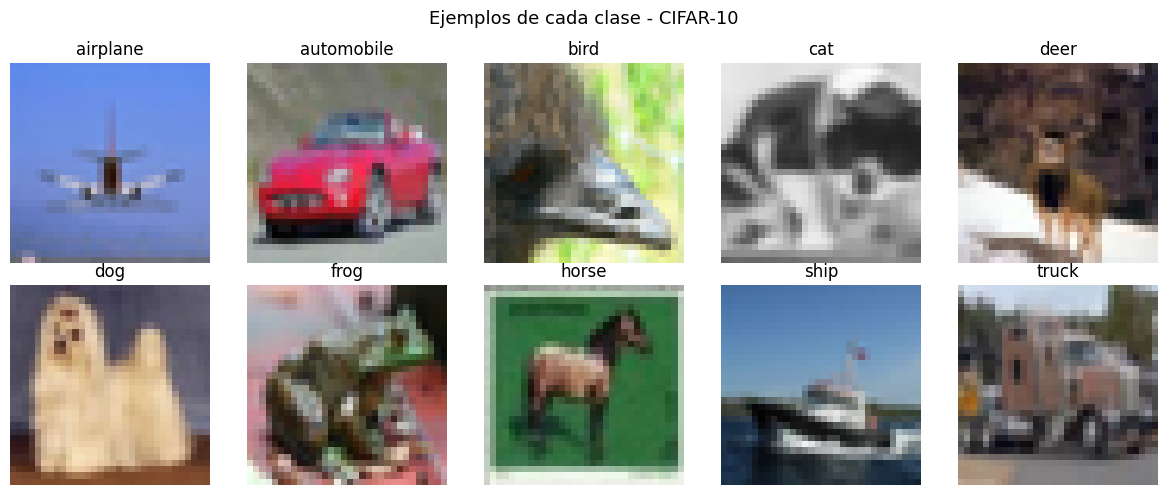

In [3]:
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, cls_idx in zip(axes.flat, range(10)):
    idx = random.choice([i for i, (_, y) in enumerate(train_dataset) if y == cls_idx])
    img, label = train_dataset[idx]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(CLASSES[label])
    ax.axis('off')
plt.suptitle('Ejemplos de cada clase - CIFAR-10', fontsize=13)
plt.tight_layout()
plt.show()

## Modelo

In [4]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
# Una clase configurable para la creación de los modelos. 
# Recibe lista de filtros por capa y ek tamaño de la capa oculta y el dropout.
# Para cada capa hacemos Conv2d + ReLU + MaxPool2d(2) y al final aplanamos y pasamos por una capa oculta con dropout antes de la capa de salida.
class CNNModel(nn.Module):
    def __init__(self, filters: list[int], fc_size: int, dropout: float = 0.3):
        super().__init__()

        conv_layers = []
        in_ch = 3  # 3 canales (RGB)
        for out_ch in filters:
            conv_layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2, stride=2),
            ]
            in_ch = out_ch
        self.features = nn.Sequential(*conv_layers)

        # Después de N capas de MaxPool2d(2), el spatial size es 32 / 2^N
        spatial = 32 // (2 ** len(filters))
        flat_size = in_ch * spatial * spatial

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, fc_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_size, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

## Optimizador y función de pérdida

In [6]:
from torch.optim import Adam

# CrossEntropyLoss porque es un problema de clasificación multiclase.
loss_fn = nn.CrossEntropyLoss()

# Adam como optimizador.
# Como lo único que va a cambiar entre los modelos es la arquitectura, defino los demás hiperparámetros aquí.
LEARNING_RATE = 1e-3
EPOCHS        = 20
BATCH_SIZE    = 64

print(f"Loss    : CrossEntropyLoss")
print(f"Opt     : Adam  (lr={LEARNING_RATE})")
print(f"Épocas  : {EPOCHS}")
print(f"Batch   : {BATCH_SIZE}")

Loss    : CrossEntropyLoss
Opt     : Adam  (lr=0.001)
Épocas  : 20
Batch   : 64


## Entrenamiento

In [7]:
from torch.utils.data import DataLoader
from tqdm import tqdm

def train_model(model, epochs=EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE):
    model = model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct = 0.0, 0
        for images, labels in tqdm(train_loader, desc=f"Época {epoch}/{epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(images)
            correct += outputs.argmax(dim=1).eq(labels).sum().item()
        train_loss = running_loss / len(train_dataset)
        train_acc  = correct / len(train_dataset)

        model.eval()
        running_loss, correct = 0.0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                running_loss += loss_fn(outputs, labels).item() * len(images)
                correct += outputs.argmax(dim=1).eq(labels).sum().item()
        test_loss = running_loss / len(test_dataset)
        test_acc  = correct / len(test_dataset)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        print(f"Época {epoch:2d} | Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}  Acc: {test_acc:.4f}")

    return history

In [8]:
def plot_curves(histories: dict):
    """Recibe un dict {nombre: history} y grafica loss y accuracy por modelo."""
    n = len(histories)
    fig, axes = plt.subplots(2, n, figsize=(6 * n, 9), sharey="row")
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, (name, hist) in enumerate(histories.items()):
        epochs_range = range(1, len(hist["train_loss"]) + 1)

        # Loss
        axes[0, col].plot(epochs_range, hist["train_loss"], label="Train")
        axes[0, col].plot(epochs_range, hist["test_loss"],  label="Test")
        axes[0, col].set_title(name)
        axes[0, col].set_xlabel("Época")
        axes[0, col].set_ylabel("Loss")
        axes[0, col].legend()

        # Accuracy
        axes[1, col].plot(epochs_range, hist["train_acc"], label="Train")
        axes[1, col].plot(epochs_range, hist["test_acc"],  label="Test")
        axes[1, col].set_xlabel("Época")
        axes[1, col].set_ylabel("Accuracy")
        axes[1, col].legend()

    plt.suptitle("Curvas de aprendizaje", fontsize=13)
    plt.tight_layout()
    plt.show()

## Entrenamiento de los 3 modelos

In [9]:
# Seed para que los 3 modelos arranquen con los mismos pesos iniciales
torch.manual_seed(42)

# Red pequeña. 2 capas conv con pocos filtros
model1 = CNNModel(filters=[32, 64], fc_size=256)
print("Modelo 1: filters=[32, 64], fc_size=256")
hist1 = train_model(model1)

Modelo 1: filters=[32, 64], fc_size=256


Época  1 | Train Loss: 1.4925  Acc: 0.4577 | Test Loss: 1.1878  Acc: 0.5699


Época  2 | Train Loss: 1.1400  Acc: 0.5941 | Test Loss: 1.1032  Acc: 0.6075


Época  3 | Train Loss: 0.9984  Acc: 0.6459 | Test Loss: 0.9690  Acc: 0.6582


Época  4 | Train Loss: 0.8945  Acc: 0.6837 | Test Loss: 0.8889  Acc: 0.6868


...

Época 16 | Train Loss: 0.3225  Acc: 0.8822 | Test Loss: 1.0469  Acc: 0.7198


Época 17 | Train Loss: 0.2974  Acc: 0.8921 | Test Loss: 1.1110  Acc: 0.7149


Época 18 | Train Loss: 0.2786  Acc: 0.8984 | Test Loss: 1.1063  Acc: 0.7179


Época 19 | Train Loss: 0.2594  Acc: 0.9074 | Test Loss: 1.1048  Acc: 0.7249


Época 20 | Train Loss: 0.2420  Acc: 0.9109 | Test Loss: 1.2287  Acc: 0.7144


In [10]:
# Red mediana. 3 capas conv
model2 = CNNModel(filters=[32, 64, 128], fc_size=256)
print("Modelo 2: filters=[32, 64, 128], fc_size=256")
hist2 = train_model(model2)

Modelo 2: filters=[32, 64, 128], fc_size=256


Época  1 | Train Loss: 1.5408  Acc: 0.4358 | Test Loss: 1.1880  Acc: 0.5784


Época  2 | Train Loss: 1.1373  Acc: 0.5938 | Test Loss: 0.9905  Acc: 0.6457


Época  3 | Train Loss: 0.9699  Acc: 0.6588 | Test Loss: 0.8739  Acc: 0.6907


Época  4 | Train Loss: 0.8442  Acc: 0.7048 | Test Loss: 0.8515  Acc: 0.7042


...

Época 16 | Train Loss: 0.2758  Acc: 0.8997 | Test Loss: 0.9479  Acc: 0.7427


Época 17 | Train Loss: 0.2679  Acc: 0.9028 | Test Loss: 0.9729  Acc: 0.7538


Época 18 | Train Loss: 0.2403  Acc: 0.9128 | Test Loss: 1.0269  Acc: 0.7539


Época 19 | Train Loss: 0.2294  Acc: 0.9173 | Test Loss: 1.0843  Acc: 0.7514


Época 20 | Train Loss: 0.2150  Acc: 0.9213 | Test Loss: 1.0720  Acc: 0.7565


In [11]:
# Red mediana con FC más grande
model3 = CNNModel(filters=[32, 64, 128], fc_size=512)
print("Modelo 3: filters=[32, 64, 128], fc_size=512")
hist3 = train_model(model3)

Modelo 3: filters=[32, 64, 128], fc_size=512


Época  1 | Train Loss: 1.5077  Acc: 0.4473 | Test Loss: 1.2080  Acc: 0.5618


Época  2 | Train Loss: 1.1056  Acc: 0.6049 | Test Loss: 0.9702  Acc: 0.6610


Época  3 | Train Loss: 0.9034  Acc: 0.6806 | Test Loss: 0.8692  Acc: 0.6966


Época  4 | Train Loss: 0.7821  Acc: 0.7246 | Test Loss: 0.7846  Acc: 0.7288


...

Época 16 | Train Loss: 0.1918  Acc: 0.9308 | Test Loss: 1.0145  Acc: 0.7533


Época 17 | Train Loss: 0.1787  Acc: 0.9360 | Test Loss: 1.0718  Acc: 0.7582


Época 18 | Train Loss: 0.1670  Acc: 0.9399 | Test Loss: 1.1386  Acc: 0.7415


Época 19 | Train Loss: 0.1506  Acc: 0.9456 | Test Loss: 1.1450  Acc: 0.7483


Época 20 | Train Loss: 0.1541  Acc: 0.9444 | Test Loss: 1.1143  Acc: 0.7539


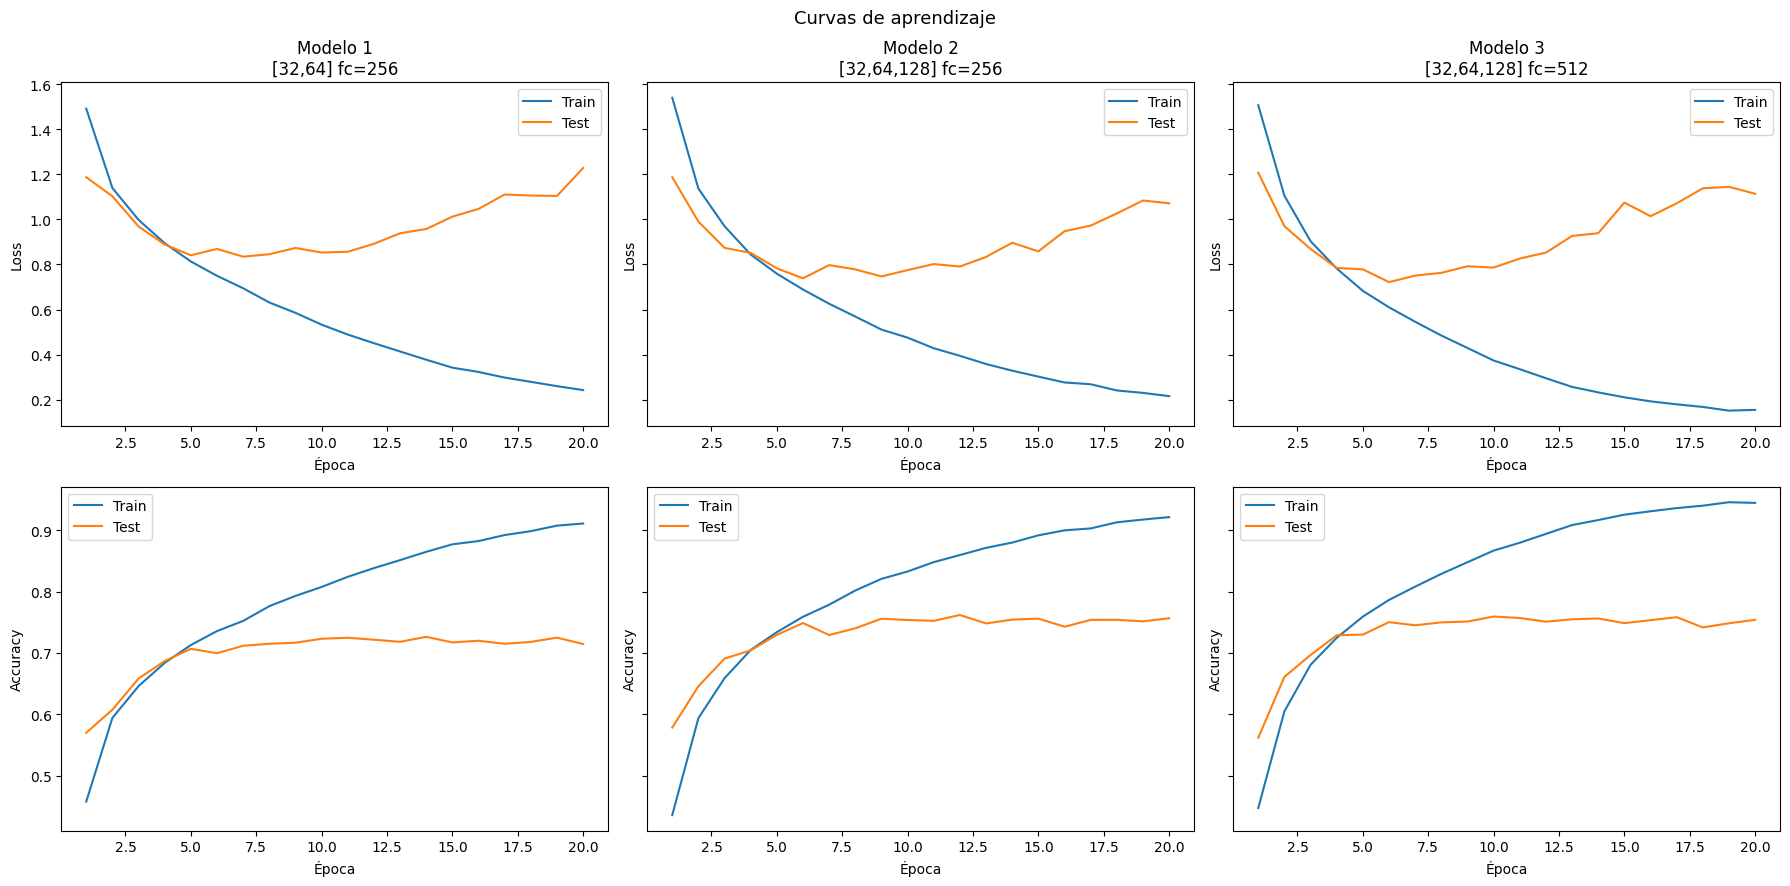

In [12]:
histories = {
    "Modelo 1\n[32,64] fc=256":    hist1,
    "Modelo 2\n[32,64,128] fc=256": hist2,
    "Modelo 3\n[32,64,128] fc=512": hist3,
}
plot_curves(histories)

## Evaluación del mejor modelo

In [13]:
results = {
    "Modelo 1 [32,64] fc=256":     hist1["test_acc"][-1],
    "Modelo 2 [32,64,128] fc=256":  hist2["test_acc"][-1],
    "Modelo 3 [32,64,128] fc=512":  hist3["test_acc"][-1],
}

print("Test Accuracy por modelo")
for name, acc in results.items():
    print(f"  {name}: {acc:.4f} ({acc*100:.2f}%)")

best_name  = max(results, key=results.get)
best_model = {"Modelo 1 [32,64] fc=256": model1,
              "Modelo 2 [32,64,128] fc=256": model2,
              "Modelo 3 [32,64,128] fc=512": model3}[best_name]

print(f"\nMejor modelo: {best_name}  →  {results[best_name]*100:.2f}% accuracy")

Test Accuracy por modelo
  Modelo 1 [32,64] fc=256: 0.7144 (71.44%)
  Modelo 2 [32,64,128] fc=256: 0.7565 (75.65%)
  Modelo 3 [32,64,128] fc=512: 0.7539 (75.39%)

Mejor modelo: Modelo 2 [32,64,128] fc=256  →  75.65% accuracy


## Clasificación de imágenes arbitrarias

In [14]:
from PIL import Image

# El mismo pipeline que se aplica al dataset: redimensionar a 32x32, convertir a RGB y normalizar a [0,1]
inference_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),          # Transforma a tensor
])

def classify_image(image_path: str) -> str:
    img = Image.open(image_path).convert("RGB")  # 3 canales
    tensor = inference_transform(img).unsqueeze(0).to(device)

    best_model.eval()
    with torch.no_grad():
        output = best_model(tensor)
        pred   = output.argmax(dim=1).item()

    return CLASSES[pred]

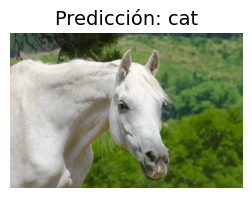

In [16]:
# Path de mi imagen. Cambiar para poner otras imágenes.
image_path = "caballo.webp"

label = classify_image(image_path)

img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title(f"Predicción: {label}", fontsize=14)
plt.axis("off")
plt.show()

# Reflexiones personales

Algo que me dí cuenta, tanto en esta actividad como la otra de CNN, es que el rendimiento de las primeras épocas de la CNN es muy bueno, pero luego se estanca, y en este caso, empeora el rendimiento para el test. Me imagino que es porque el problema no es muy muy complejo. Aún así de los resultados, y de las gráficas más específicamente, podemos ver cómo los 3 modelos tienen una forma parecida: llegan a su punto más bajo de loss entre la 5ta y 8va época, y luego empieza a subir. Esto nos muestra un claro overfitting, sobre todo porque la línea que sí baja en todo momento, es la del train.

De los modelos, yo les pondría un early stop o les bajaría las épocas para evitar este overfitting. Fuera de eso, la verdad es que los 3 modelos tuvieron un performance muy parecido. Si acaso, solo el primer modelo se quedó un poco atrás. Por otro lado, los 2 modelos de redes medianas tuvieron una diferencia de accuracy muy pequeña.